In [41]:
import os
import rasterio
import geopandas as gpd
import numpy as np
import cv2
import json
from rasterio.features import rasterize

# ============================================================
# CONFIG
# ============================================================

TARGET_SIZE = 1024

OUT_ROOT = r"C:\git\Master-Thesis-GEOAI\train_sam\patches"
OUT_IMG = os.path.join(OUT_ROOT, "images")
OUT_MASK = os.path.join(OUT_ROOT, "masks")
OUT_POINTS = os.path.join(OUT_ROOT, "points")

os.makedirs(OUT_IMG, exist_ok=True)
os.makedirs(OUT_MASK, exist_ok=True)
os.makedirs(OUT_POINTS, exist_ok=True)

# Dataset 1
IMG_DIR_1 = r"C:\git\Master-Thesis-GEOAI\train_sam\data\processedBuildingLabels\processedBuildingLabels\3band\3band"
GEO_DIR_1 = r"C:\git\Master-Thesis-GEOAI\train_sam\data\processedBuildingLabels\processedBuildingLabels\vectordata\geojson\geojson"

# Dataset 2
IMG_DIR_2 = r"C:\git\Master-Thesis-GEOAI\train_sam\data\SN2_buildings_train_AOI_5_Khartoum\AOI_5_Khartoum_Train\RGB-PanSharpen"
GEO_DIR_2 = r"C:\git\Master-Thesis-GEOAI\train_sam\data\SN2_buildings_train_AOI_5_Khartoum\AOI_5_Khartoum_Train\geojson\buildings"


# ============================================================
# IMAGE NORMALIZATION (16-bit → 8-bit SAFE)
# ============================================================

def convert_to_uint8(image):
    if image.dtype == np.uint16:
        image = image.astype(np.float32)
        image /= image.max()
        image *= 255
        image = image.astype(np.uint8)
    else:
        image = image.astype(np.uint8)
    return image


# ============================================================
# RASTERIZE BUILDINGS
# ============================================================

def rasterize_buildings(image_path, geojson_path):
    with rasterio.open(image_path) as src:
        image = src.read([1, 2, 3])
        image = np.moveaxis(image, 0, -1)

        height = src.height
        width = src.width
        transform = src.transform

        gdf = gpd.read_file(geojson_path)

        if len(gdf) == 0:
            mask = np.zeros((height, width), dtype=np.uint8)
        else:
            shapes = [(geom, 1) for geom in gdf.geometry]
            mask = rasterize(
                shapes,
                out_shape=(height, width),
                transform=transform,
                fill=0,
                dtype=np.uint8
            )

    return image, mask


# ============================================================
# POINT SAMPLING
# ============================================================

def sample_positive_points(mask, num_points=3):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return []

    idx = np.random.choice(len(xs), min(num_points, len(xs)), replace=False)
    return [[int(xs[i]), int(ys[i])] for i in idx]


def sample_negative_points(mask, num_points=5):
    ys, xs = np.where(mask == 0)
    if len(xs) == 0:
        return []

    idx = np.random.choice(len(xs), min(num_points, len(xs)), replace=False)
    return [[int(xs[i]), int(ys[i])] for i in idx]


# ============================================================
# MAIN PROCESSING
# ============================================================

saved = len(os.listdir(OUT_IMG))


def process_dataset(img_dir, geo_dir, limit=500):
    global saved

    images = sorted(os.listdir(img_dir))[:limit]

    for img_name in images:
        img_path = os.path.join(img_dir, img_name)

        img_id = os.path.splitext(img_name)[0]
        img_id = img_id.replace("3band_", "").replace("RGB-PanSharpen_", "")

        matches = [f for f in os.listdir(geo_dir) if img_id in f]
        if not matches:
            continue

        geo_path = os.path.join(geo_dir, matches[0])

        image, mask = rasterize_buildings(img_path, geo_path)

        # Skip empty patches
        if np.sum(mask) < 50:
            continue

        # Convert image to uint8
        image = convert_to_uint8(image)

        # ------------------------------------------------
        # RESIZE TO 1024 × 1024
        # ------------------------------------------------

        h, w = mask.shape

        image_resized = cv2.resize(
            image,
            (TARGET_SIZE, TARGET_SIZE),
            interpolation=cv2.INTER_LINEAR
        )

        mask_resized = cv2.resize(
            mask,
            (TARGET_SIZE, TARGET_SIZE),
            interpolation=cv2.INTER_NEAREST
        )

        # Scale prompt points
        scale_x = TARGET_SIZE / w
        scale_y = TARGET_SIZE / h

        positive = sample_positive_points(mask)
        negative = sample_negative_points(mask)

        positive_scaled = [
            [int(p[0] * scale_x), int(p[1] * scale_y)]
            for p in positive
        ]

        negative_scaled = [
            [int(p[0] * scale_x), int(p[1] * scale_y)]
            for p in negative
        ]

        if len(positive_scaled) == 0:
            continue

        # ------------------------------------------------
        # SAVE
        # ------------------------------------------------

        img_out = os.path.join(OUT_IMG, f"{saved:06d}.png")
        mask_out = os.path.join(OUT_MASK, f"{saved:06d}.png")
        json_out = os.path.join(OUT_POINTS, f"{saved:06d}.json")

        cv2.imwrite(img_out, cv2.cvtColor(image_resized, cv2.COLOR_RGB2BGR))
        cv2.imwrite(mask_out, mask_resized * 255)

        with open(json_out, "w") as f:
            json.dump({
                "positive_points": positive_scaled,
                "negative_points": negative_scaled
            }, f)

        saved += 1


print("Processing Dataset 1...")
process_dataset(IMG_DIR_1, GEO_DIR_1, limit=500)

print("Processing Dataset 2...")
process_dataset(IMG_DIR_2, GEO_DIR_2, limit=500)

print(f"\n✅ Total patches saved: {saved}")


Processing Dataset 1...
Processing Dataset 2...

✅ Total patches saved: 713


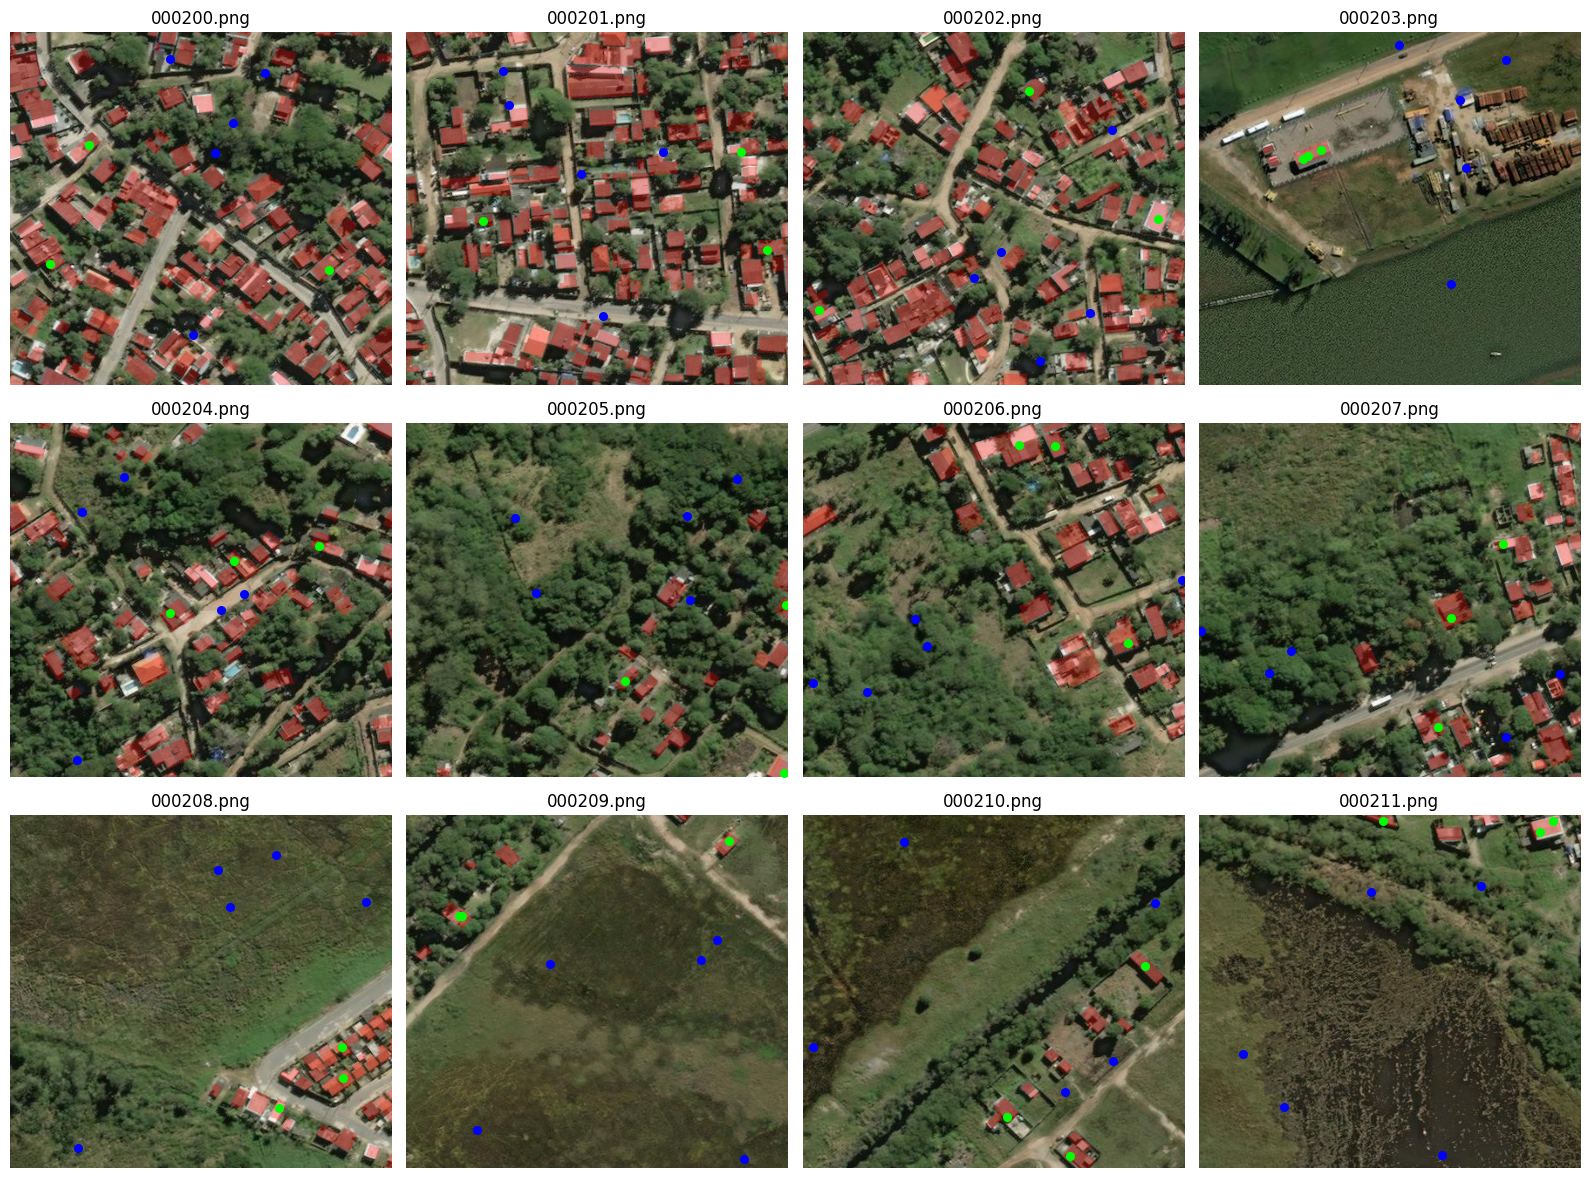

In [40]:
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = r"C:\git\Master-Thesis-GEOAI\train_sam\patches\images"
MASK_DIR = r"C:\git\Master-Thesis-GEOAI\train_sam\patches\masks"
POINT_DIR = r"C:\git\Master-Thesis-GEOAI\train_sam\patches\points"

files = sorted(os.listdir(IMG_DIR))[200:212]  # show first 12

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, file in zip(axes, files):
    img_path = os.path.join(IMG_DIR, file)
    mask_path = os.path.join(MASK_DIR, file)
    point_path = os.path.join(POINT_DIR, file.replace(".png", ".json"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, 0)

    # Create overlay
    overlay = img.copy()
    overlay[mask > 0] = [255, 0, 0]  # red buildings
    blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    ax.imshow(blended)

    # Plot points
    if os.path.exists(point_path):
        with open(point_path) as f:
            pts = json.load(f)

        for x, y in pts["positive_points"]:
            ax.scatter(x, y, c="lime", s=30)

        for x, y in pts["negative_points"]:
            ax.scatter(x, y, c="blue", s=30)

    ax.set_title(file)
    ax.axis("off")

plt.tight_layout()
plt.show()
